In [13]:
import pandas as pd
from IPython.display import display
import ipywidgets as widgets
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# Upload Button
# -------------------------------
upload = widgets.FileUpload(accept='.csv', multiple=False)
display(upload)

print("👉 Upload your CSV file above, then run next cell")


FileUpload(value={}, accept='.csv', description='Upload')

👉 Upload your CSV file above, then run next cell


Dataset Loaded!

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


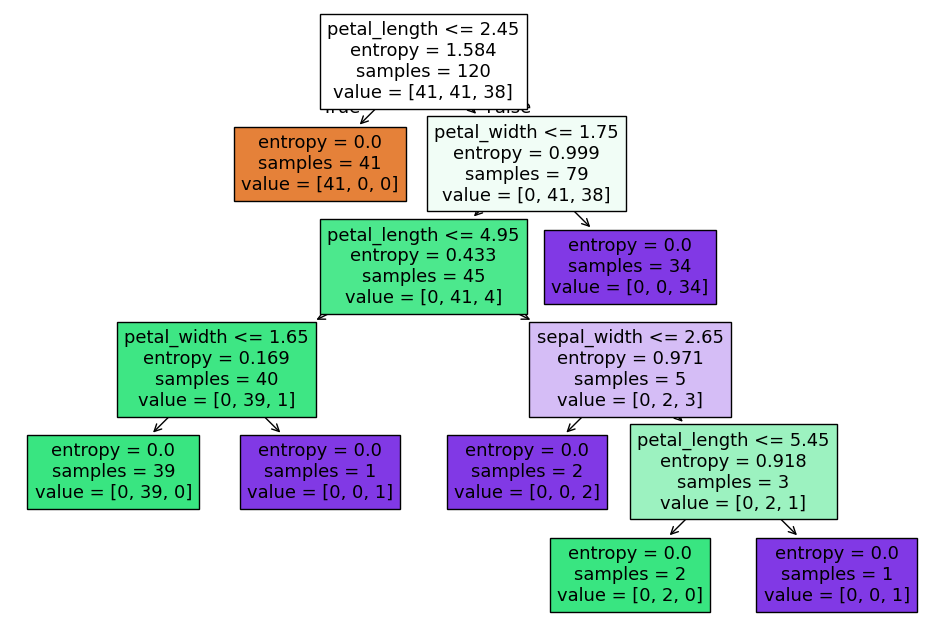


Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.89      0.89      0.89         9
           2       0.92      0.92      0.92        12

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



In [15]:
# Get uploaded file
file_name = list(upload.value.keys())[0]
content = upload.value[file_name]['content']

# Read file
data = pd.read_csv(BytesIO(content))

print("Dataset Loaded!\n")
print(data.head())

# -------------------------------
# Preprocessing
# -------------------------------
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# -------------------------------
# Train ID3
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()
# -------------------------------
# Results
# -------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))